## Sentiment Analysis

In this exercise we use the IMDb-dataset, which we will use to perform a sentiment analysis. The code below assumes that the data is placed in the same folder as this notebook. We see that the reviews are loaded as a pandas dataframe, and print the beginning of the first few reviews.

In [1]:
import numpy as np
import pandas as pd

reviews = pd.read_csv('reviews.txt', header=None)
labels = pd.read_csv('labels.txt', header=None)
Y = (labels=='positive').astype(np.int_)

print(type(reviews))
print(reviews.head())

<class 'pandas.core.frame.DataFrame'>
                                                   0
0  bromwell high is a cartoon comedy . it ran at ...
1  story of a man who has unnatural feelings for ...
2  homelessness  or houselessness as george carli...
3  airport    starts as a brand new luxury    pla...
4  brilliant over  acting by lesley ann warren . ...


**(a)** Split the reviews and labels in test, train and validation sets. The train and validation sets will be used to train your model and tune hyperparameters, the test set will be saved for testing. Use the `CountVectorizer` from `sklearn.feature_extraction.text` to create a Bag-of-Words representation of the reviews. Only use the 10,000 most frequent words (use the `max_features`-parameter of `CountVectorizer`).

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# --- Konverter reviews til en liste af strings ---
reviews_list = reviews[0].tolist()   # hver review som én string
y = Y[0].values                      # labels som numpy-array (0=negativ, 1=positiv)

# --- Split 1: 80 % train+val  /  20 % test ---
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    reviews_list, y, test_size=0.2, random_state=42, stratify=y
)

# --- Split 2: af de 80 % → 75 % train / 25 % val  (= 60/20/20 totalt) ---
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train_raw)}  |  Val: {len(X_val_raw)}  |  Test: {len(X_test_raw)}")

# --- Bag-of-Words med de 10.000 hyppigste ord ---
vectorizer = CountVectorizer(max_features=10_000)

X_train = vectorizer.fit_transform(X_train_raw)   # fit kun på træningsdata
X_val   = vectorizer.transform(X_val_raw)          # transform validation
X_test  = vectorizer.transform(X_test_raw)         # transform test

print(f"\nBag-of-Words matrix (train): {X_train.shape}")
print(f"Bag-of-Words matrix (val):   {X_val.shape}")
print(f"Bag-of-Words matrix (test):  {X_test.shape}")

Train: 15000  |  Val: 5000  |  Test: 5000



Bag-of-Words matrix (train): (15000, 10000)
Bag-of-Words matrix (val):   (5000, 10000)
Bag-of-Words matrix (test):  (5000, 10000)


**(b)** Explore the representation of the reviews. How is a single word represented? How about a whole review?

**Svar (b):**

- **Et enkelt ord** repræsenteres som en one-hot vektor af længde 10.000 — alle nuller undtagen indekset for det pågældende ord.
- **En hel review** repræsenteres som en tælle-vektor (count vector) af længde 10.000, hvor hvert element angiver hvor mange gange det tilsvarende ord forekommer i reviewet. De fleste elementer er 0 (sparse), fordi ét review kun bruger en lille del af hele vocabulary.

In [3]:
# --- Vocabulary: de 10.000 ord som vectorizeren kender ---
vocab = vectorizer.get_feature_names_out()
print(f"Antal ord i vocabulary: {len(vocab)}")
print(f"De første 20 ord (alfabetisk): {vocab[:20]}")
print(f"De sidste 20 ord:              {vocab[-20:]}")

# --- Enkelt ord: find indekset for "good" ---
word = "good"
idx = vectorizer.vocabulary_[word]
print(f"\nOrdet '{word}' har indeks {idx} i vocabulary")

# --- Hvordan ser én review ud som BoW-vektor? ---
print(f"\nReview 0 (rå tekst, første 120 tegn): '{X_train_raw[0][:120]}...'")
review_vec = X_train[0]                          # sparse row
print(f"Dens BoW-vektor er en sparse matrix med shape: {review_vec.shape}")
print(f"Antal unikke ord i reviewet (non-zero): {review_vec.nnz}")

# Vis de første 10 ord der optræder i reviewet
non_zero_indices = review_vec.toarray().flatten().nonzero()[0]
print(f"\nEksempel – de første 10 ord i reviewet og deres counts:")
for i in non_zero_indices[:10]:
    print(f"  '{vocab[i]}' → count = {review_vec[0, i]}")

Antal ord i vocabulary: 10000
De første 20 ord (alfabetisk): ['aaron' 'abandon' 'abandoned' 'abbott' 'abc' 'abhay' 'abigail'
 'abilities' 'ability' 'able' 'aboard' 'abomination' 'aboriginal'
 'abortion' 'abound' 'about' 'above' 'abraham' 'abroad' 'abrupt']
De sidste 20 ord:              ['youthful' 'youtube' 'zane' 'zany' 'zealand' 'zelah' 'zelda' 'zenia'
 'zero' 'zeta' 'zizek' 'zodiac' 'zombi' 'zombie' 'zombies' 'zone' 'zoo'
 'zoom' 'zorro' 'zu']

Ordet 'good' har indeks 3835 i vocabulary

Review 0 (rå tekst, første 120 tegn): 'i did not expect a lot from this movie  after the terrible  life is a miracle  . it turns out that this movie is ten tim...'
Dens BoW-vektor er en sparse matrix med shape: (1, 10000)
Antal unikke ord i reviewet (non-zero): 113

Eksempel – de første 10 ord i reviewet og deres counts:
  'able' → count = 1
  'above' → count = 1
  'acting' → count = 1
  'after' → count = 1
  'and' → count = 3
  'are' → count = 2
  'arrogant' → count = 1
  'attitude' → count = 1
  '

**(c)** Train a neural network with a single hidden layer on the dataset, tuning the relevant hyperparameters to optimize accuracy. 

In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# ============================================================
# 1) Baseline: ét skjult lag med 100 neuroner
# ============================================================
mlp_base = MLPClassifier(
    hidden_layer_sizes=(100,),    # ét skjult lag, 100 neuroner
    activation='relu',            # aktiveringsfunktion
    solver='adam',                # optimizer
    max_iter=20,                  # antal epoker
    early_stopping=True,          # stop tidligt hvis val-loss stagnerer
    validation_fraction=0.1,
    random_state=42,
    verbose=True                  # vis loss per epoke
)
mlp_base.fit(X_train, y_train)

train_acc = accuracy_score(y_train, mlp_base.predict(X_train))
val_acc   = accuracy_score(y_val,   mlp_base.predict(X_val))
print(f"\nBaseline  →  Train acc: {train_acc:.4f}  |  Val acc: {val_acc:.4f}")

Iteration 1, loss = 0.38801696
Validation score: 0.880000


Iteration 2, loss = 0.18961385
Validation score: 0.884000


Iteration 3, loss = 0.12132245
Validation score: 0.884667


Iteration 4, loss = 0.08313803
Validation score: 0.882667


Iteration 5, loss = 0.05832088
Validation score: 0.885333


...

Iteration 13, loss = 0.00424642
Validation score: 0.878667


Iteration 14, loss = 0.00350252
Validation score: 0.876667


Iteration 15, loss = 0.00297449
Validation score: 0.876000


Iteration 16, loss = 0.00255459
Validation score: 0.874667
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.



Baseline  →  Train acc: 0.9832  |  Val acc: 0.8732


In [5]:
# ============================================================
# 2) Hyperparameter-tuning: prøv forskellige lag-størrelser
#    og regulariseringsstyrker (alpha) på validation-sættet
# ============================================================
import warnings
warnings.filterwarnings('ignore')   # skjul ConvergenceWarnings under tuning

configs = [
    {'hidden': (64,),   'alpha': 0.0001},
    {'hidden': (128,),  'alpha': 0.0001},
    {'hidden': (128,),  'alpha': 0.001},
]

best_val_acc = 0
best_config  = None
best_model   = None

print(f"{'Hidden layers':<18} {'Alpha':<10} {'Train acc':<12} {'Val acc':<12}")
print("-" * 52)

for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden'],
        activation='relu',
        solver='adam',
        alpha=cfg['alpha'],          # L2-regularisering
        max_iter=20,                 # maks 20 epoker
        early_stopping=True,         # stop tidligt hvis val-loss stagnerer
        validation_fraction=0.1,
        random_state=42,
        verbose=False
    )
    mlp.fit(X_train, y_train)
    
    tr_acc = accuracy_score(y_train, mlp.predict(X_train))
    vl_acc = accuracy_score(y_val,   mlp.predict(X_val))
    print(f"{str(cfg['hidden']):<18} {cfg['alpha']:<10} {tr_acc:<12.4f} {vl_acc:<12.4f}")
    
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_config  = cfg
        best_model   = mlp

print(f"\n✓ Bedste konfiguration: hidden={best_config['hidden']}, alpha={best_config['alpha']}")
print(f"  Val accuracy: {best_val_acc:.4f}")

Hidden layers      Alpha      Train acc    Val acc     
----------------------------------------------------


(64,)              0.0001     0.9598       0.8896      


(128,)             0.0001     0.9332       0.8858      


(128,)             0.001      0.9335       0.8838      

✓ Bedste konfiguration: hidden=(64,), alpha=0.0001
  Val accuracy: 0.8896


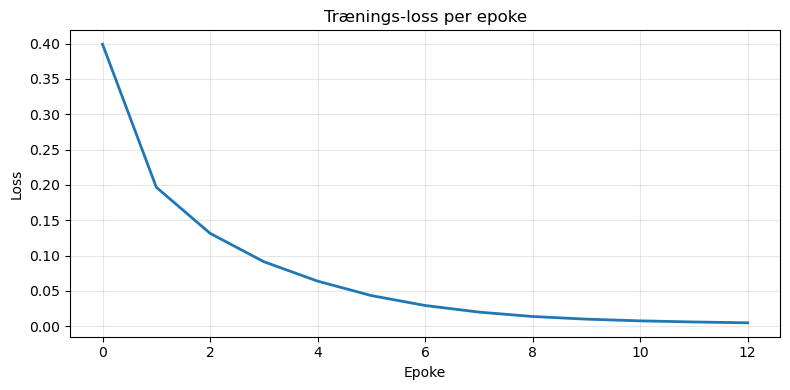

Final train acc: 0.9598
Final val acc:   0.8896


In [6]:
import matplotlib.pyplot as plt

# --- Træn den bedste model med flere epoker og vis loss-kurven ---
final_mlp = MLPClassifier(
    hidden_layer_sizes=best_config['hidden'],
    activation='relu',
    solver='adam',
    alpha=best_config['alpha'],
    max_iter=30,                  # flere epoker for at konvergere
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False
)
final_mlp.fit(X_train, y_train)

# --- Plot loss-kurve (træningsfejl per epoke) ---
plt.figure(figsize=(8, 4))
plt.plot(final_mlp.loss_curve_, linewidth=2)
plt.title('Trænings-loss per epoke')
plt.xlabel('Epoke')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train acc: {accuracy_score(y_train, final_mlp.predict(X_train)):.4f}")
print(f"Final val acc:   {accuracy_score(y_val,   final_mlp.predict(X_val)):.4f}")

**(d)** Test your sentiment-classifier on the test set.

Test accuracy: 0.8778

              precision    recall  f1-score   support

     Negativ       0.89      0.87      0.88      2500
     Positiv       0.87      0.89      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



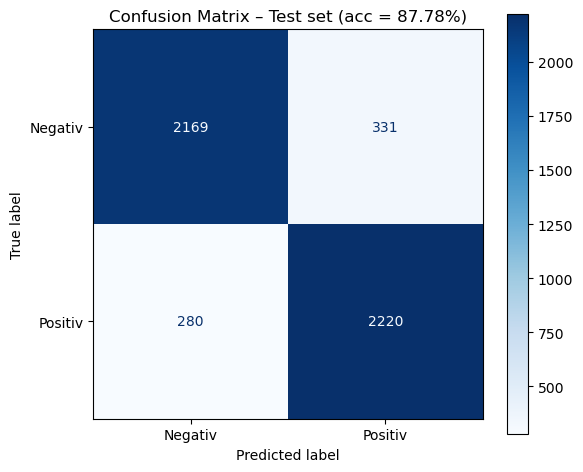

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Forudsig på test-sættet med den bedste model ---
y_pred = final_mlp.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}\n")

# --- Classification report (precision, recall, F1) ---
print(classification_report(y_test, y_pred, target_names=['Negativ', 'Positiv']))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negativ', 'Positiv'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix – Test set (acc = {test_acc:.2%})')
plt.tight_layout()
plt.show()

**(e)** Use the classifier to classify a few sentences you write yourselves. 

In [8]:
# --- Test modellen med egne sætninger ---
custom_reviews = [
    "This movie was absolutely fantastic, I loved every minute of it!",
    "Terrible acting, boring plot, complete waste of time.",
    "Not bad, but not great either. It was okay I guess.",
    "One of the best films I have ever seen, truly a masterpiece.",
    "I fell asleep halfway through, it was so dull and predictable.",
    "The visuals were stunning but the story made no sense at all."
]

# Transformer sætningerne med samme vectorizer (Bag-of-Words)
X_custom = vectorizer.transform(custom_reviews)

# Forudsig sentiment
predictions = final_mlp.predict(X_custom)
probas      = final_mlp.predict_proba(X_custom)

print(f"{'Review (forkortet)':<60} {'Prediction':<12} {'P(pos)':<8}")
print("-" * 80)
for review, pred, prob in zip(custom_reviews, predictions, probas):
    label = "Positiv ✓" if pred == 1 else "Negativ ✗"
    print(f"{review[:57]+'...' if len(review)>57 else review:<60} {label:<12} {prob[1]:.2%}")

Review (forkortet)                                           Prediction   P(pos)  
--------------------------------------------------------------------------------
This movie was absolutely fantastic, I loved every minute... Positiv ✓    68.55%
Terrible acting, boring plot, complete waste of time.        Negativ ✗    15.64%
Not bad, but not great either. It was okay I guess.          Negativ ✗    34.88%
One of the best films I have ever seen, truly a masterpie... Positiv ✓    68.79%
I fell asleep halfway through, it was so dull and predict... Negativ ✗    21.06%
The visuals were stunning but the story made no sense at ... Positiv ✓    50.72%
